# Data Cleaning and Feature Engineering Pipeline¶

## 1: Project Planning & Problem Framing



## What is Data Analysis?

- Data Analysis is the process of collecting, cleaning, transforming, and interpreting data to extract meaningful insights.
- It helps in identifying patterns, trends, and relationships within data to support decision-making.

---

## Steps in a Data Science Project

- Data Collection: Gathering data from multiple sources such as CSV, JSON, databases, and APIs.  
- Data Cleaning & Preprocessing: Handling missing values, removing duplicates, and standardizing data formats.  
- Exploratory Data Analysis (EDA): Understanding data distribution, patterns, and relationships.  
- Feature Engineering: Creating meaningful features to improve model performance.  
- Model Building: Training machine learning models (not required in this project).  
- Evaluation & Deployment: Assessing model performance and deploying it for real-world use.

---

## Problem Framing (Binary Classification)

- The dataset is framed as a binary classification problem where the goal is to predict whether a customer will make a purchase or not.  
- Input features include customer demographics, transaction details, and behavioral attributes.  
- The target variable is `purchased`, where:
  - 1 indicates the customer made a purchase  
  - 0 indicates the customer did not make a purchase  

- The objective of this project is to prepare a clean and feature-rich dataset suitable for building a machine learning model in the future.

## Importing necessary libraries

In [2]:
# Data manipulation and analysis
import pandas as pd  # used for handling datasets (DataFrame operations)

# Numerical computations
import numpy as np  # used for numerical operations and array handling

# Data visualization
import matplotlib.pyplot as plt  # used for plotting basic graphs (histograms, boxplots)
import seaborn as sns  # used for advanced statistical visualizations (heatmaps, pairplots)

# Database handling
import sqlite3  # used to connect and execute SQL queries in SQLite database

# API handling
import requests  # used to fetch data from APIs

# Statistical methods
from scipy.stats import zscore  # used for Z-score based outlier detection
from scipy.stats.mstats import winsorize  # used to cap extreme values (winsorization)

# Missing value imputation
from sklearn.impute import SimpleImputer  # used for mean/median/mode imputation
from sklearn.impute import KNNImputer  # used for KNN-based imputation of missing values

# Enable experimental features
from sklearn.experimental import enable_iterative_imputer  # required to use IterativeImputer

# Advanced imputation
from sklearn.impute import IterativeImputer  # used for MICE (multivariate imputation)

# Encoding techniques
from sklearn.preprocessing import LabelEncoder  # used to convert categorical labels to numbers
from sklearn.preprocessing import OrdinalEncoder  # used for encoding ordered categorical data

# Feature transformation
from sklearn.preprocessing import FunctionTransformer  # used to apply custom transformations (e.g., log)
from sklearn.preprocessing import PowerTransformer  # used to normalize data distribution (Box-Cox / Yeo-Johnson)

# Feature scaling
from sklearn.preprocessing import StandardScaler  # used to standardize data (mean=0, std=1)
from sklearn.preprocessing import MinMaxScaler  # used to scale data between 0 and 1
from sklearn.preprocessing import MaxAbsScaler  # used to scale data based on maximum absolute value
from sklearn.preprocessing import RobustScaler  # used to scale data robust to outliers
from sklearn.preprocessing import Normalizer  # used to normalize rows to unit norm

# Pipeline transformations
from sklearn.compose import ColumnTransformer  # used to apply different transformations to different columns

# Automated EDA
from ydata_profiling import ProfileReport  # used to generate automated exploratory data analysis reports

## 2: Data Importing and Understanding

In [3]:

# Load customer data from CSV
customers = pd.read_csv("customers.csv")
print("\nCustomers Dataset (CSV):")
print(customers.head())

# Load transaction data from JSON
transactions = pd.read_json("transactions.json")
print("\nTransactions Dataset (JSON):")
print(transactions.head())

# Load product data from SQL file using SQLite
conn = sqlite3.connect("products.db")

with open("products.sql", "r") as f:
    conn.executescript(f.read())

products = pd.read_sql_query("SELECT * FROM products", conn)
print("\nProducts Dataset (SQL):")
print(products.head())

# Load additional user data from API
url = "https://dummyjson.com/users"
response = requests.get(url)
api_data = response.json()

users = pd.DataFrame(api_data['users'])
print("\nUsers Dataset (API):")
print(users.head())




Customers Dataset (CSV):
   customer_id    name  age  gender       city  income
0          101   Aarav   24    Male     Mumbai   45000
1          102    Diya   30  Female      Delhi   55000
2          103   Kabir   27    Male  Bangalore   48000
3          104   Meera   35  Female  Ahmedabad   60000
4          105  Vivaan   40    Male       Pune   75000

Transactions Dataset (JSON):
  transaction_id  customer_id product_id  amount payment_mode       date
0           T001          101       P001     499          UPI 2025-10-01
1           T002          103       P003    1299  Credit Card 2025-10-02
2           T003          104       P002     699   Debit Card 2025-10-03
3           T004          105       P005    1999          UPI 2025-10-05
4           T005          107       P004     899         Cash 2025-10-07

Products Dataset (SQL):
  product_id       product_name     category  price  stock
0       P001          Earphones  Electronics    499     50
1       P002  Bluetooth Speaker  

In [4]:

# Merge customer and transaction data using customer_id
df = pd.merge(customers, transactions, on="customer_id", how="left")

# Merge with product data using product_id
df = pd.merge(df, products, on="product_id", how="left")

# Merge with API user data using customer_id and id
df = pd.merge(df, users, left_on="customer_id", right_on="id", how="left")

# Display combined dataset
print("\nFinal Merged Dataset:")
print(df.head())

# Display dataset structure and summary
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Final Merged Dataset:
   customer_id    name  age_x gender_x       city  income transaction_id  \
0          101   Aarav     24     Male     Mumbai   45000           T001   
1          102    Diya     30   Female      Delhi   55000           T007   
2          103   Kabir     27     Male  Bangalore   48000           T002   
3          104   Meera     35   Female  Ahmedabad   60000           T003   
4          105  Vivaan     40     Male       Pune   75000           T004   

  product_id  amount payment_mode  ... address macAddress university  bank  \
0       P001     499          UPI  ...     NaN        NaN        NaN   NaN   
1       P003    1499  Credit Card  ...     NaN        NaN        NaN   NaN   
2       P003    1299  Credit Card  ...     NaN        NaN        NaN   NaN   
3       P002     699   Debit Card  ...     NaN        NaN        NaN   NaN   
4       P005    1999          UPI  ...     NaN        NaN        NaN   NaN   

   company  ein  ssn userAgent crypto  role  
0    

## 3: Exploratory Data Analysis (EDA)

In [45]:
# Import required libraries for data analysis and visualization

import pandas as pd              # Used for data manipulation and analysis
import matplotlib.pyplot as plt  # Used for plotting graphs
import seaborn as sns            # Used for advanced data visualization

# Load the dataset from CSV file into a pandas DataFrame
df = pd.read_csv("customer_purchase_dataset.csv")

# Display the first 5 rows to understand the structure of the dataset
print("Dataset Preview:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
print(df.info())

# Display statistical summary of numerical columns
print("\nStatistical Summary:")
print(df.describe())

Dataset Preview:
   customer_id    name   age  gender       city    income transaction_id  \
0        467.0     NaN  56.0  Female  Bangalore  357950.0         T00001   
1        915.0   Kabir  25.0    Male       Pune   96820.0         T00002   
2        841.0  Vivaan  36.0  Female     Mumbai   57194.0         T00003   
3        152.0   Meera  53.0  Female       Pune   80263.0         T00004   
4        860.0   Aarav  19.0  Female       Pune       NaN         T00005   

  product_id  amount payment_mode        date  
0       P006   960.0         Cash  2025-09-28  
1       P002  1738.0          UPI  2025-05-02  
2        NaN  1582.0  Credit Card  2025-03-29  
3       P003   230.0          UPI         NaN  
4       P005  1615.0   Debit Card  2025-10-21  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id 

### 1) Univariate Analysis

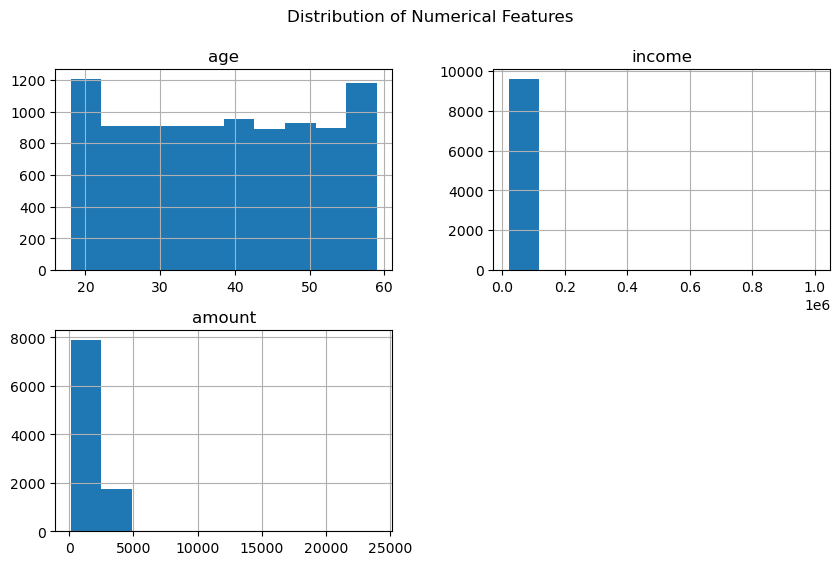

In [46]:
# Task 1: Visualize distribution of numerical columns using histograms

num_cols = ["age", "income", "amount"]

df[num_cols].hist(figsize=(10, 6))
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [47]:
# Task 2: Identify skewed variables using skewness

print("Skewness of Numerical Features:")
print(df[num_cols].skew())

Skewness of Numerical Features:
age       0.005368
income    9.867085
amount    8.038523
dtype: float64


In [48]:
# Task 3: Generate automated insights using Pandas Profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Univariate Analysis Report", explorative=True)
profile.to_file("univariate_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/11 [00:00<?, ?it/s]
%|███████▌                                                                           | 1/11 [00:00<00:02,  4.97it/s]
%|███████████████                                                                    | 2/11 [00:00<00:01,  6.99it/s]
%|██████████████████████████████▏                                                    | 4/11 [00:00<00:01,  6.81it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
import webbrowser
webbrowser.open("univariate_eda_report.html")

True

### Bivariate Analysis

In [50]:
# Task 1: Create target column (purchased = 1 or 0 based on amount)

df["purchased"] = df["amount"].apply(lambda x: 1 if x > 1000 else 0)

print("Dataset after adding 'purchased' column:")
df

Dataset after adding 'purchased' column:


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,purchased
0,467.0,NaN,56.0,Female,Bangalore,357950.0,T00001,P006,960.0,Cash,2025-09-28,0
1,915.0,Kabir,25.0,Male,Pune,96820.0,T00002,P002,1738.0,UPI,2025-05-02,1
2,841.0,Vivaan,36.0,Female,Mumbai,57194.0,T00003,NaN,1582.0,Credit Card,2025-03-29,1
3,152.0,Meera,53.0,Female,Pune,80263.0,T00004,P003,230.0,UPI,NaN,0
4,860.0,Aarav,19.0,Female,Pune,NaN,T00005,P005,1615.0,Debit Card,2025-10-21,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,833.0,Aryan,NaN,Female,Chennai,42333.0,T03534,P003,574.0,UPI,2025-12-22,0
10196,376.0,Diya,58.0,Female,Ahmedabad,29415.0,T02976,P005,2993.0,Credit Card,2025-06-10,1
10197,659.0,Riya,19.0,Female,Kolkata,53690.0,T02677,P003,NaN,UPI,2025-03-19,0
10198,920.0,Kabir,56.0,Female,Bangalore,21658.0,T04372,P005,391.0,Debit Card,2025-10-04,0


In [51]:
# Task 2: Correlate numerical features with the target column

num_cols = ["age", "income", "amount", "purchased"]

correlation = df[num_cols].corr()

print("\nCorrelation Matrix:")
print(correlation)

print("\nCorrelation with 'purchased':")
print(correlation["purchased"].sort_values(ascending=False))


Correlation Matrix:
                age    income    amount  purchased
age        1.000000  0.022720  0.021144   0.008000
income     0.022720  1.000000  0.008932   0.003445
amount     0.021144  0.008932  1.000000   0.469598
purchased  0.008000  0.003445  0.469598   1.000000

Correlation with 'purchased':
purchased    1.000000
amount       0.469598
age          0.008000
income       0.003445
Name: purchased, dtype: float64



Average Income by Purchase Group:
purchased
0    64682.267990
1    65133.657956
Name: income, dtype: float64


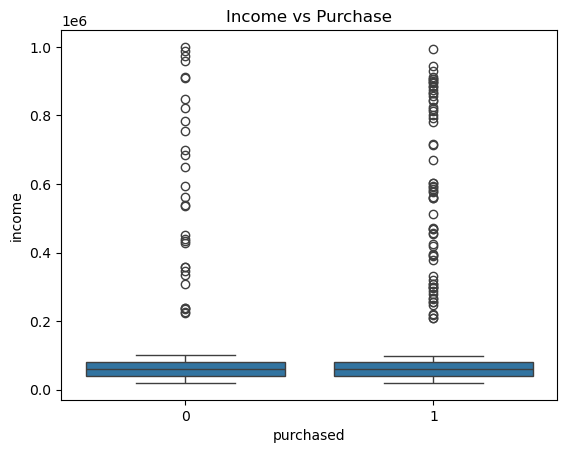


Insight:
Insight:The income distribution for both purchased (1) and not purchased (0) groups is quite similar, with significant overlap in the boxplot.
Although there are high-value outliers in both groups, there is no strong visible difference in median income.
This suggests that income alone may not be a strong predictor of purchase behavior in this dataset.


In [52]:
# Task 3: Compare means and visualize relationships (Income vs Purchase)

print("\nAverage Income by Purchase Group:")
print(df.groupby("purchased")["income"].mean())

sns.boxplot(x="purchased", y="income", data=df)
plt.title("Income vs Purchase")
plt.show()

print("\nInsight:")
print("Insight:The income distribution for both purchased (1) and not purchased (0) groups is quite similar, with significant overlap in the boxplot.") 
print("Although there are high-value outliers in both groups, there is no strong visible difference in median income.")
print("This suggests that income alone may not be a strong predictor of purchase behavior in this dataset.")

### Multivariate Analysis

Correlation Matrix:
                age    income    amount  purchased
age        1.000000  0.022720  0.021144   0.008000
income     0.022720  1.000000  0.008932   0.003445
amount     0.021144  0.008932  1.000000   0.469598
purchased  0.008000  0.003445  0.469598   1.000000


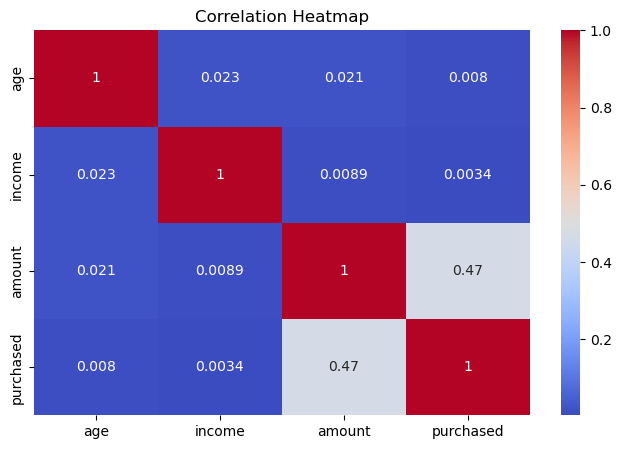


Insight:
The feature 'amount' shows a moderate positive correlation (~0.47) with 'purchased', as the target variable is derived from it.
Features like 'age' and 'income' have near-zero correlation with 'purchased', indicating weak direct influence.
Low correlation among independent variables suggests minimal multicollinearity in the dataset.


In [53]:
# Task 1: Analyze relationships using correlation heatmap

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["age", "income", "amount", "purchased"]

correlation = df[num_cols].corr()

print("Correlation Matrix:")
print(correlation)

plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("\nInsight:")
print("The feature 'amount' shows a moderate positive correlation (~0.47) with 'purchased', as the target variable is derived from it.")
print("Features like 'age' and 'income' have near-zero correlation with 'purchased', indicating weak direct influence.")
print("Low correlation among independent variables suggests minimal multicollinearity in the dataset.")

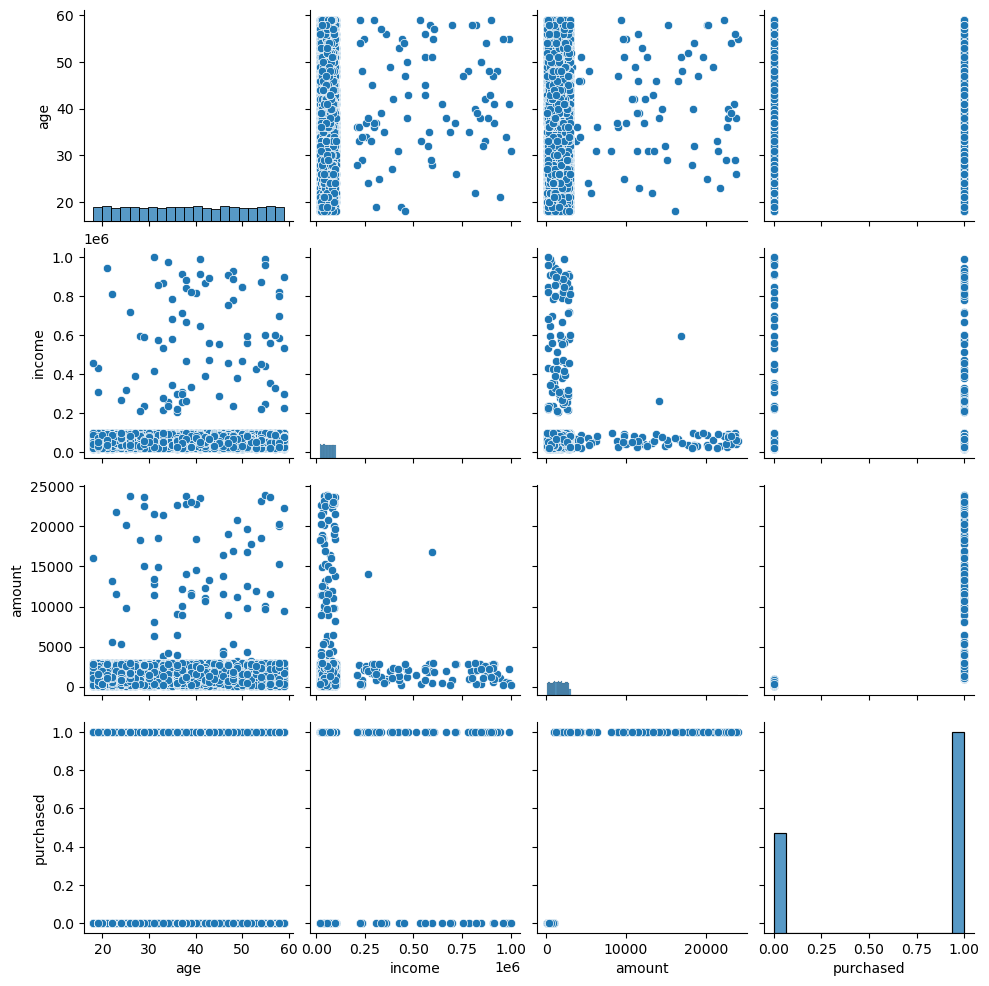


Insight:
Pairplot shows pairwise relationships between age, income, amount, and purchased.
There is no clear linear separation between purchased classes, indicating weak direct relationships.
Income and amount show the presence of extreme outliers, which may affect analysis.
Most data points are concentrated in lower ranges, while a few high-value points create skewness.
Purchased values appear as two distinct bands (0 and 1), confirming it is a binary target variable.


In [54]:
# Task 2: Explore relationships using pairplot

sns.pairplot(df[["age", "income", "amount", "purchased"]])
plt.show()
print("\nInsight:")
print("Pairplot shows pairwise relationships between age, income, amount, and purchased.")
print("There is no clear linear separation between purchased classes, indicating weak direct relationships.")
print("Income and amount show the presence of extreme outliers, which may affect analysis.")
print("Most data points are concentrated in lower ranges, while a few high-value points create skewness.")
print("Purchased values appear as two distinct bands (0 and 1), confirming it is a binary target variable.")

In [55]:
# Task 3: Perform grouped statistical analysis

print("Average values grouped by city:")
grouped_city = df.groupby("city")[["income", "amount"]].mean()

print(grouped_city)

print("\nInsight:")
print("Grouped analysis shows how income and spending vary across cities.")
print("Some cities may have higher average spending, indicating regional patterns.")

Average values grouped by city:
                 income       amount
city                                
Ahmedabad  67637.462403  1709.854310
Bangalore  65493.216696  1622.699468
Chennai    65287.867021  1658.281139
Delhi      61831.780508  1677.556692
Kolkata    63855.230769  1638.018405
Mumbai     64874.182979  1618.655319
Pune       65772.919201  1694.402249
Surat      65843.792683  1681.122271

Insight:
Grouped analysis shows how income and spending vary across cities.
Some cities may have higher average spending, indicating regional patterns.


## 4: Handling Missing Data

In [57]:
# Check missing values in each column

print("Missing Values Count:")
print(df.isnull().sum())
print("\nTotal Missing:", df.isnull().sum().sum())

Missing Values Count:
customer_id       508
name              511
age               515
gender            513
city              508
income            509
transaction_id    508
product_id        507
amount            507
payment_mode      507
date              511
purchased           0
dtype: int64

Total Missing: 5604


### Task 1: Simple Imputer (Numerical + Categorical)

In [58]:
from sklearn.impute import SimpleImputer

# Create a copy for Simple Imputer
df_simple = df.copy()

num_cols = ["age", "income", "amount"]
cat_cols = ["gender", "city", "payment_mode"]

# Numerical imputation (mean)
num_imputer = SimpleImputer(strategy="mean")
df_simple[num_cols] = num_imputer.fit_transform(df_simple[num_cols])

# Categorical imputation (most frequent)
cat_imputer = SimpleImputer(strategy="most_frequent")
df_simple[cat_cols] = cat_imputer.fit_transform(df_simple[cat_cols])

print("\nAfter Simple Imputation:")
print(df_simple.isnull().sum())
print("\nTotal Missing:", df.isnull().sum().sum())


After Simple Imputation:
customer_id       508
name              511
age                 0
gender              0
city                0
income              0
transaction_id    508
product_id        507
amount              0
payment_mode        0
date              511
purchased           0
dtype: int64

Total Missing: 5604


### Task 2: Missing Indicator + Random Sample Imputation

In [59]:


# Create a copy for Random Imputation
df_random = df.copy()
# Missing indicator
df_random["income_missing"] = df_random["income"].isnull().astype(int)

# Random sampling for 'income'
missing_count = df_random["income"].isnull().sum()

random_sample = df_random["income"].dropna().sample(missing_count, random_state=42)
random_sample.index = df_random[df_random["income"].isnull()].index

df_random.loc[df_random["income"].isnull(), "income"] = random_sample

print("\nRandom Imputation Results:")
print("Missing After:")
print(df_random.isnull().sum())
print("Total Missing After:", df_random.isnull().sum().sum())




Random Imputation Results:
Missing After:
customer_id       508
name              511
age               515
gender            513
city              508
income              0
transaction_id    508
product_id        507
amount            507
payment_mode      507
date              511
purchased           0
income_missing      0
dtype: int64
Total Missing After: 5095


### Task 3: KNN Imputer (Multivariate Imputation)

In [62]:
from sklearn.impute import KNNImputer

df_knn = df.copy()

#using knn for mumerical columns taking 5 neighbour values
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])

print("\nKNN Imputer Results:")
print("Missing After:")
print(df_knn.isnull().sum())
print("\n Total Missing After:", df_knn.isnull().sum().sum())


KNN Imputer Results:
Missing After:
customer_id       508
name              511
age                 0
gender            513
city              508
income              0
transaction_id    508
product_id        507
amount              0
payment_mode      507
date              511
purchased           0
dtype: int64

 Total Missing After: 4073


### Task 4: MICE (Iterative Imputer)

In [63]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Create a copy of the dataset
df_mice = df.copy()

# Apply MICE imputation on numerical columns
mice_imputer = IterativeImputer(random_state=42)
df_mice[num_cols] = mice_imputer.fit_transform(df_mice[num_cols])

# Display missing values after imputation
print("\nMICE Imputer Results:")
print("Missing Values After:")
print(df_mice.isnull().sum())

# Display total missing count after imputation
print("\nTotal Missing After:", df_mice.isnull().sum().sum())


MICE Imputer Results:
Missing Values After:
customer_id       508
name              511
age                 0
gender            513
city              508
income              0
transaction_id    508
product_id        507
amount              0
payment_mode      507
date              511
purchased           0
dtype: int64

Total Missing After: 4073


### Complete Case Analysis (Dropping Missing Values)

In [64]:
# Create a copy of the dataset
df_drop = df.copy()

# Drop all rows with missing values
df_drop = df_drop.dropna()

# Display dataset shape before and after dropping
print("\nComplete Case Analysis:")
print("Original Shape:", df.shape)
print("Shape After Dropping:", df_drop.shape)

# Verify no missing values remain
print("Missing Values After Drop:")
print(df_drop.isnull().sum())

# Calculate percentage of data removed
data_loss = (1 - len(df_drop) / len(df)) * 100
print("\nPercentage of Data Lost:", data_loss, "%")


Complete Case Analysis:
Original Shape: (10200, 12)
Shape After Dropping: (5787, 12)
Missing Values After Drop:
customer_id       0
name              0
age               0
gender            0
city              0
income            0
transaction_id    0
product_id        0
amount            0
payment_mode      0
date              0
purchased         0
dtype: int64

Percentage of Data Lost: 43.26470588235294 %


### Creating clean dataframe 

In [66]:
# Import required libraries
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

# Create clean dataset from original
df_clean = df.copy()

num_cols = ["age", "income", "amount"]
cat_cols = ["gender", "city", "payment_mode"]

# Handle numerical missing values (MICE)
mice = IterativeImputer(random_state=42)
df_clean[num_cols] = mice.fit_transform(df_clean[num_cols])

# Handle categorical missing values (most frequent)
cat_imp = SimpleImputer(strategy="most_frequent")
df_clean[cat_cols] = cat_imp.fit_transform(df_clean[cat_cols])

# Drop any remaining missing values
df_clean = df_clean.dropna()

# Check
print("df_clean created successfully")
print("Shape:", df_clean.shape)
print("Remaining missing:", df_clean.isnull().sum().sum())

df_clean created successfully
Shape: (7884, 12)
Remaining missing: 0


## 5: Outlier Detection & Handling

### Task 1: Z-Score Method

In [67]:
# Import required libraries
import numpy as np
from scipy.stats import zscore

# Create a copy
df_z = df_clean.copy()

num_cols = ["age", "income", "amount"]

# Compute Z-scores
z_scores = np.abs(zscore(df_z[num_cols]))

# Remove rows where Z-score > 3
df_z = df_z[(z_scores < 3).all(axis=1)]

# Output
print("Z-Score Method:")
print("Original Shape:", df_clean.shape)
print("After Removing Outliers:", df_z.shape)

print("\nInsight:")
print("Rows with extreme values beyond 3 standard deviations were removed.")

Z-Score Method:
Original Shape: (7884, 12)
After Removing Outliers: (7755, 12)

Insight:
Rows with extreme values beyond 3 standard deviations were removed.


### Task 2: IQR Method

In [68]:
# Create a copy
df_iqr = df_clean.copy()

# Apply IQR filtering
for col in num_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]

# Output
print("\nIQR Method:")
print("Original Shape:", df_clean.shape)
print("After Removing Outliers:", df_iqr.shape)

print("\nInsight:")
print("Values outside the IQR range were removed, making this method robust for skewed data.")


IQR Method:
Original Shape: (7884, 12)
After Removing Outliers: (7745, 12)

Insight:
Values outside the IQR range were removed, making this method robust for skewed data.


### Task 3: Percentile Method

In [69]:
# Create a copy
df_percentile = df_clean.copy()

# Remove extreme 1% values
for col in num_cols:
    lower = df_percentile[col].quantile(0.01)
    upper = df_percentile[col].quantile(0.99)

    df_percentile = df_percentile[
        (df_percentile[col] >= lower) &
        (df_percentile[col] <= upper)
    ]

# Output
print("\nPercentile Method:")
print("Original Shape:", df_clean.shape)
print("After Removing Outliers:", df_percentile.shape)

print("\nInsight:")
print("Top and bottom 1% extreme values were removed to reduce the impact of outliers.")


Percentile Method:
Original Shape: (7884, 12)
After Removing Outliers: (7570, 12)

Insight:
Top and bottom 1% extreme values were removed to reduce the impact of outliers.


### Task 4: Winsorization

In [70]:
# Import winsorize
from scipy.stats.mstats import winsorize

# Create a copy
df_winsor = df_clean.copy()

# Cap extreme values instead of removing
for col in num_cols:
    df_winsor[col] = winsorize(df_winsor[col], limits=[0.01, 0.01])

# Output
print("\nWinsorization Method:")
print(df_winsor[num_cols].describe())

print("\nInsight:")
print("Extreme values were capped instead of removed, preserving dataset size while reducing their effect.")


Winsorization Method:
               age        income       amount
count  7884.000000   7884.000000  7884.000000
mean     38.500914  60722.477980  1572.217147
std      11.845497  22859.476045   819.290043
min      18.000000  20785.000000   132.000000
25%      29.000000  41309.500000   889.000000
50%      38.482275  62584.500000  1640.000000
75%      48.000000  80104.250000  2253.000000
max      59.000000  99992.000000  2995.000000

Insight:
Extreme values were capped instead of removed, preserving dataset size while reducing their effect.


## 6: Handling Mixed & Date/Time Variables

### Task 1: Convert Date Column to Datetime

In [71]:
# Convert 'date' column to datetime format

df_clean["date"] = pd.to_datetime(df_clean["date"])

# Check result
print("Date Column Type:")
print(df_clean["date"].dtype)

Date Column Type:
datetime64[ns]


### Task 2: Create New Feature (Days Since Last Purchase)

In [73]:
# Create reference date (latest date in dataset)
reference_date = df_clean["date"].max()

# Calculate days since last purchase
df_clean["days_since_last_purchase"] = (reference_date - df_clean["date"]).dt.days

# Check output
print("\nNew Feature: days_since_last_purchase")
print(df_clean[["date", "days_since_last_purchase"]])


New Feature: days_since_last_purchase
            date  days_since_last_purchase
1     2025-05-02                       243
4     2025-10-21                        71
5     2025-10-04                        88
6     2025-09-10                       112
7     2025-06-19                       195
...          ...                       ...
10194 2025-05-17                       228
10195 2025-12-22                         9
10196 2025-06-10                       204
10197 2025-03-19                       287
10198 2025-10-04                        88

[7884 rows x 2 columns]


### Task 3: Handle Mixed Variables (IDs)

In [77]:
# Extract numeric part from transaction_id

df_clean["transaction_id_num"] = df_clean["transaction_id"].str.extract("(\d+)").astype(int)

# Extract numeric part from product_id

df_clean["product_id_num"] = df_clean["product_id"].str.extract("(\d+)").astype(int)

# Check result
print("\nConverted ID Columns:")
print(df_clean[["transaction_id", "transaction_id_num", 
                "product_id", "product_id_num"]])


Converted ID Columns:
      transaction_id  transaction_id_num product_id  product_id_num
1             T00002                   2       P002               2
4             T00005                   5       P005               5
5             T00006                   6       P005               5
6             T00007                   7       P005               5
7             T00008                   8       P001               1
...              ...                 ...        ...             ...
10194         T01238                1238       P001               1
10195         T03534                3534       P003               3
10196         T02976                2976       P005               5
10197         T02677                2677       P003               3
10198         T04372                4372       P005               5

[7884 rows x 4 columns]


## 7: Encoding Categorical Data

### Task 1: Label Encoding

In [76]:
# Import library
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_label = df_clean.copy()

# Initialize encoder
le = LabelEncoder()

# Apply label encoding to 'gender'
df_label["gender_encoded"] = le.fit_transform(df_label["gender"])

# Output
print("Label Encoding (Gender):")
print(df_label[["gender", "gender_encoded"]])

Label Encoding (Gender):
       gender  gender_encoded
1        Male               1
4      Female               0
5        Male               1
6        Male               1
7      Female               0
...       ...             ...
10194  Female               0
10195  Female               0
10196  Female               0
10197  Female               0
10198  Female               0

[7884 rows x 2 columns]


### Task 2: One-Hot Encoding

In [78]:
# Create a copy
df_onehot = df_clean.copy()

# Apply one-hot encoding to 'city' and 'payment_mode'
df_onehot = pd.get_dummies(df_onehot, columns=["city", "payment_mode"], drop_first=True)

# Output
print("\nOne-Hot Encoding Applied:")
print(df_onehot.head())


One-Hot Encoding Applied:
   customer_id    name   age  gender        income transaction_id product_id  \
1        915.0   Kabir  25.0    Male  96820.000000         T00002       P002   
4        860.0   Aarav  19.0  Female  64983.275690         T00005       P005   
5        531.0    Diya  19.0    Male  25311.000000         T00006       P005   
6        413.0    Riya  50.0    Male  73707.000000         T00007       P005   
7        835.0  Vivaan  42.0  Female  64987.630675         T00008       P001   

        amount       date  purchased  ...  city_Bangalore  city_Chennai  \
1  1738.000000 2025-05-02          1  ...           False         False   
4  1615.000000 2025-10-21          1  ...           False         False   
5  1055.000000 2025-10-04          1  ...           False         False   
6  1667.616141 2025-09-10          0  ...           False          True   
7  2658.000000 2025-06-19          1  ...           False         False   

   city_Delhi  city_Kolkata  city_Mumbai 

### Task 3: Ordinal Encoding (example-based)

In [98]:
# Create a copy
df_ordinal = df_clean.copy()

# Create an example ordinal column (income level)
df_ordinal["income_level"] = pd.cut(
    df_ordinal["income"],
    bins=[0, 40000, 70000, 1000000],
    labels=["Low", "Medium", "High"]
)

# Apply ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
df_ordinal["income_level_encoded"] = ord_enc.fit_transform(df_ordinal[["income_level"]])

# Output
print("\nOrdinal Encoding (Income Level):")
print(df_ordinal[["income", "income_level", "income_level_encoded"]])


Ordinal Encoding (Income Level):
             income income_level  income_level_encoded
1      96820.000000         High                   0.0
4      64983.275690       Medium                   2.0
5      25311.000000          Low                   1.0
6      73707.000000         High                   0.0
7      64987.630675       Medium                   2.0
...             ...          ...                   ...
10194  40389.000000       Medium                   2.0
10195  42333.000000       Medium                   2.0
10196  29415.000000          Low                   1.0
10197  53690.000000       Medium                   2.0
10198  21658.000000          Low                   1.0

[7884 rows x 3 columns]


### Task 4: Encoding Numerical Feature (Binning)

In [82]:
# Create a copy
df_binning = df_clean.copy()

# Create income groups
df_binning["income_group"] = pd.cut(
    df_binning["income"],
    bins=[0, 40000, 70000, 1000000],
    labels=["Low", "Medium", "High"]
)

# Output
print("\nBinned Income Feature:")
print(df_binning[["income", "income_group"]])


Binned Income Feature:
             income income_group
1      96820.000000         High
4      64983.275690       Medium
5      25311.000000          Low
6      73707.000000         High
7      64987.630675       Medium
...             ...          ...
10194  40389.000000       Medium
10195  42333.000000       Medium
10196  29415.000000          Low
10197  53690.000000       Medium
10198  21658.000000          Low

[7884 rows x 2 columns]


## 8: Feature Scaling

### Task 1: StandardScaler

In [102]:
# Import library StandardScaler
from sklearn.preprocessing import StandardScaler

# Create a copy
df_standard = df_clean.copy()

num_cols = ["age", "income", "amount"]

# Apply StandardScaler
scaler = StandardScaler()
df_standard[num_cols] = scaler.fit_transform(df_standard[num_cols])

# Output
print("Standard Scaler Applied:")
print(df_standard[num_cols].head())

Standard Scaler Applied:
        age    income    amount
1 -1.139823  0.496259  0.046812
4 -1.646377 -0.010445 -0.033596
5 -1.646377 -0.641856 -0.399681
6  0.970817  0.128400  0.000800
7  0.295413 -0.010375  0.648238


### Task 2: MinMaxScaler

In [103]:
# Import library MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

df_minmax = df_clean.copy()

scaler = MinMaxScaler()
df_minmax[num_cols] = scaler.fit_transform(df_minmax[num_cols])

print("\nMinMax Scaler Applied:")
print(df_minmax[num_cols].head())


MinMax Scaler Applied:
        age    income    amount
1  0.170732  0.078386  0.068627
4  0.024390  0.045898  0.063474
5  0.024390  0.005415  0.040012
6  0.780488  0.054800  0.065679
7  0.585366  0.045903  0.107173


### Task 3: MaxAbsScaler

In [104]:
# Import library MaxAbsScaler
from sklearn.preprocessing import MaxAbsScaler

df_maxabs = df_clean.copy()

scaler = MaxAbsScaler()
df_maxabs[num_cols] = scaler.fit_transform(df_maxabs[num_cols])

print("\nMaxAbs Scaler Applied:")
print(df_maxabs[num_cols].head())


MaxAbs Scaler Applied:
        age    income    amount
1  0.423729  0.096824  0.072513
4  0.322034  0.064986  0.067382
5  0.322034  0.025312  0.044017
6  0.847458  0.073710  0.069577
7  0.711864  0.064990  0.110898


### Task 4: RobustScaler

In [105]:
# Import library RobustScaler

from sklearn.preprocessing import RobustScaler

df_robust = df_clean.copy()

scaler = RobustScaler()
df_robust[num_cols] = scaler.fit_transform(df_robust[num_cols])

print("\nRobust Scaler Applied:")
print(df_robust[num_cols].head())


Robust Scaler Applied:
        age    income    amount
1 -0.709593  0.882478  0.071848
4 -1.025383  0.061832 -0.018328
5 -1.025383 -0.960787 -0.428886
6  0.606196  0.286701  0.020246
7  0.185143  0.061945  0.746334


### Task 5: Normalizer

In [106]:
# Import library Normalizer

from sklearn.preprocessing import Normalizer

df_norm = df_clean.copy()

scaler = Normalizer()
df_norm[num_cols] = scaler.fit_transform(df_norm[num_cols])

print("\nNormalizer Applied:")
print(df_norm[num_cols].head())


Normalizer Applied:
        age    income    amount
1  0.000258  0.999839  0.017948
4  0.000292  0.999691  0.024845
5  0.000750  0.999132  0.041645
6  0.000678  0.999744  0.022619
7  0.000646  0.999164  0.040866


### Task 6: ColumnTransformer

In [107]:
# Import library ColumnTransformer, StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), ["city", "payment_mode"])
    ]
)

# Apply transformation
df_transformed = preprocessor.fit_transform(df_clean)

print("\nColumnTransformer Applied:")
print(df_transformed[:5])


ColumnTransformer Applied:
[[-1.13982304e+00  4.96258996e-01  4.68119843e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00]
 [-1.64637677e+00 -1.04446164e-02 -3.35960472e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [-1.64637677e+00 -6.41856479e-01 -3.99681394e-01  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 9.70817489e-01  1.28399524e-01  8.00378409e-04  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [ 2.95412519e-01 -1.03753038e-02  6.48237911e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.0

## 9: Feature Construction & Transformation

### Task 1: Create Interaction Feature

In [90]:
# Create a copy
df_feat = df_clean.copy()

# Create purchase_per_day feature
# (using days_since_last_purchase from Step 6)

df_feat["purchase_per_day"] = df_feat["amount"] / (df_feat["days_since_last_purchase"] + 1)

# Output
print("New Feature: purchase_per_day")
print(df_feat[["amount", "days_since_last_purchase", "purchase_per_day"]].head())

print("\nInsight:")
print("This feature captures spending intensity relative to recency.")

New Feature: purchase_per_day
        amount  days_since_last_purchase  purchase_per_day
1  1738.000000                       243          7.122951
4  1615.000000                        71         22.430556
5  1055.000000                        88         11.853933
6  1667.616141                       112         14.757665
7  2658.000000                       195         13.561224

Insight:
This feature captures spending intensity relative to recency.


### Task 2: FunctionTransformer (Log Transformation)

In [91]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Apply log transformation to reduce skewness
log_transformer = FunctionTransformer(np.log1p)

df_feat["income_log"] = log_transformer.fit_transform(df_feat[["income"]])
df_feat["amount_log"] = log_transformer.fit_transform(df_feat[["amount"]])

# Output
print("\nLog Transformation Applied:")
print(df_feat[["income", "income_log", "amount", "amount_log"]].head())

print("\nInsight:")
print("Log transformation reduces skewness and stabilizes variance.")


Log Transformation Applied:
         income  income_log       amount  amount_log
1  96820.000000   11.480619  1738.000000    7.461066
4  64983.275690   11.081901  1615.000000    7.387709
5  25311.000000   10.139034  1055.000000    6.962243
6  73707.000000   11.207867  1667.616141    7.419750
7  64987.630675   11.081968  2658.000000    7.885705

Insight:
Log transformation reduces skewness and stabilizes variance.


### Task 3: PowerTransformer

In [92]:
from sklearn.preprocessing import PowerTransformer

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method="yeo-johnson")

df_feat[["income_power", "amount_power"]] = pt.fit_transform(df_feat[["income", "amount"]])

# Output
print("\nPower Transformation Applied:")
print(df_feat[["income_power", "amount_power"]].head())

print("\nInsight:")
print("Power transformation makes data more normally distributed.")


Power Transformation Applied:
   income_power  amount_power
1      1.108863      0.315790
4      0.325332      0.208445
5     -1.785196     -0.373629
6      0.579397      0.255068
7      0.325469      0.981090

Insight:
Power transformation makes data more normally distributed.


### Task 4: Binning (Income Groups)

In [93]:
# Create equal-width bins for income
df_feat["income_bin"] = pd.cut(
    df_feat["income"],
    bins=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# Output
print("\nIncome Binning:")
print(df_feat[["income", "income_bin"]].head())

print("\nInsight:")
print("Income values are grouped into categories for easier interpretation.")


Income Binning:
         income income_bin
1  96820.000000        Low
4  64983.275690        Low
5  25311.000000        Low
6  73707.000000        Low
7  64987.630675        Low

Insight:
Income values are grouped into categories for easier interpretation.


### Task 5: Binary Feature (Frequent Buyer)

In [94]:
# Create frequent buyer flag based on amount threshold
threshold = df_feat["amount"].mean()

df_feat["frequent_buyer"] = df_feat["amount"].apply(lambda x: 1 if x > threshold else 0)

# Output
print("\nFrequent Buyer Feature:")
print(df_feat[["amount", "frequent_buyer"]].head())

print("\nInsight:")
print("Customers spending above average are marked as frequent buyers.")


Frequent Buyer Feature:
        amount  frequent_buyer
1  1738.000000               1
4  1615.000000               0
5  1055.000000               0
6  1667.616141               1
7  2658.000000               1

Insight:
Customers spending above average are marked as frequent buyers.


## 10: Final Output

In [95]:
# Create final dataset (already processed)
df_final = df_feat.copy()

# Export to CSV
df_final.to_csv("processed_customer_data.csv", index=False)

print("Final dataset exported successfully.")
print("Final Shape:", df_final.shape)
print("\nRemaining Missing Values:")
print(df_final.isnull().sum().sum())

Final dataset exported successfully.
Final Shape: (7884, 22)

Remaining Missing Values:
0



# Final Summary: Data Cleaning and Feature Engineering Pipeline

## Techniques Used

- Data cleaning using multiple imputation techniques:
  - Simple Imputer (mean and most frequent)
  - Random Sample Imputation with missing indicator
  - KNN Imputer
  - MICE (Iterative Imputer)
  - Complete Case Analysis (row removal)

- Outlier detection and handling:
  - Z-score method
  - Interquartile Range (IQR) method
  - Percentile method
  - Winsorization (capping extreme values)

- Date and mixed variable handling:
  - Conversion of date column to datetime format
  - Creation of recency-based feature (days_since_last_purchase)
  - Extraction of numeric values from mixed-type IDs

- Encoding techniques:
  - Label Encoding for binary variables
  - One-Hot Encoding for nominal variables
  - Ordinal Encoding for ordered categories
  - Binning of numerical features (income groups)

- Feature scaling:
  - StandardScaler
  - MinMaxScaler
  - MaxAbsScaler
  - RobustScaler
  - Normalizer
  - ColumnTransformer for combined transformations

- Feature engineering:
  - Interaction feature (purchase_per_day)
  - Log transformation using FunctionTransformer
  - Power transformation using Yeo-Johnson method
  - Binning of income into categories
  - Binary feature creation (frequent_buyer)

---

## Biggest Issues in Raw Data

- Presence of missing values in both numerical and categorical columns
- Extreme outliers in income and transaction amount
- Skewed data distributions
- Mixed-format variables (IDs containing text and numbers)
- Lack of meaningful derived features for analysis

---

## Best Methods Used

- **Imputation:**
  - MICE (Iterative Imputer) for numerical features
  - Most Frequent Imputation for categorical features

- **Outlier Handling:**
  - IQR method and Winsorization (effective for skewed data)

- **Scaling:**
  - StandardScaler and RobustScaler depending on data distribution

---

## Final Conclusion

A complete data preprocessing and feature engineering pipeline was implemented to transform raw, unstructured data into a clean and structured dataset. Missing values were handled effectively, outliers were treated, and new meaningful features were created. The final dataset is optimized for machine learning applications and ready for further modeling.